## This dataset contains 300,000 social media ad campaign records across Facebook, Instagram, Pinterest, and Twitter — including spend, impressions, clicks, conversions, ROI, and demographic targeting. This analysis compares channel performance to identify which platform underperforms and why. Note: ROI and Engagement_Score were found to be unreliable (consistent with randomly-generated values, not real business metrics) and were excluded — Click-Through Rate (CTR) is used as the primary performance measure throughout.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Social_Media_Advertising.csv')
df.head()

,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony


In [3]:
df.shape

(300000, 16)

In [4]:
#To check the types  of numbers, whether direct operation possible or not
df.dtypes

Campaign_ID           int64
Target_Audience      object
Campaign_Goal        object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
Company              object
dtype: object

In [5]:
#To check the types  of numbers, whether direct operation possible or not
df[['Acquisition_Cost', 'ROI', 'Conversion_Rate', 'Clicks', 'Impressions']].head()

,Acquisition_Cost,ROI,Conversion_Rate,Clicks,Impressions
0,$500.00,5.790000,0.15,500,3000
1,$500.00,7.210000,0.01,500,3000
2,$500.00,0.430000,0.08,500,3000
3,$500.00,0.909824,0.03,293,1937
4,$500.00,1.422828,0.13,293,1937


In [6]:
#To convert the column into float for mathematical operations
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [7]:
df['Acquisition_Cost'].dtype

dtype('float64')

In [8]:
df[['Acquisition_Cost']].head()

,Acquisition_Cost
0,500.0
1,500.0
2,500.0
3,500.0
4,500.0


In [9]:
df['CTR'] = (df['Clicks'] / df['Impressions'])*100
print(df['CTR'].round(2))

0         16.67
1         16.67
2         16.67
3         15.13
4         15.13
          ...  
299995    33.33
299996    33.33
299997    30.32
299998    33.33
299999    33.33
Name: CTR, Length: 300000, dtype: float64


In [10]:
df[['Clicks', 'Impressions', 'CTR']].head()

,Clicks,Impressions,CTR
0,500,3000,16.666667
1,500,3000,16.666667
2,500,3000,16.666667
3,293,1937,15.126484
4,293,1937,15.126484


In [11]:
#checking unique channels_used
df['Channel_Used'].unique()

array(['Instagram', 'Facebook', 'Pinterest', 'Twitter'], dtype=object)

In [12]:
df.groupby('Channel_Used')['CTR'].mean()

Channel_Used
Facebook     32.135894
Instagram    32.131680
Pinterest    29.239640
Twitter      32.158472
Name: CTR, dtype: float64

In [13]:
df.groupby('Channel_Used')['ROI'].mean()

Channel_Used
Facebook     3.986930
Instagram    4.008786
Pinterest    0.716431
Twitter      4.002236
Name: ROI, dtype: float64

In [14]:
#To check if the reason for low CTR and ROI of Pinterest is if it is underrepresented in data
df.groupby('Channel_Used')['CTR'].count()

Channel_Used
Facebook     75164
Instagram    75101
Pinterest    75082
Twitter      74653
Name: CTR, dtype: int64

In [15]:
#To check reason behind Pinterest's low ROI and CTR
df.groupby('Channel_Used')['Acquisition_Cost'].mean()

Channel_Used
Facebook     7745.022816
Instagram    7726.252813
Pinterest    7769.738763
Twitter      7774.121680
Name: Acquisition_Cost, dtype: float64

In [16]:
#To check reason behind Pinterest's low ROI and CTR
df.groupby('Channel_Used')['Conversion_Rate'].mean()

Channel_Used
Facebook     0.079870
Instagram    0.079764
Pinterest    0.080042
Twitter      0.080363
Name: Conversion_Rate, dtype: float64

In [17]:
#To check the distribution of Pinterest vs Facebook as the cause low ROI and CTR could not be established from the data
df[df['Channel_Used'] == 'Pinterest']['ROI'].describe()

count    75082.000000
mean         0.716431
std          0.412227
min          0.000000
25%          0.359282
50%          0.716777
75%          1.074271
max          1.429978
Name: ROI, dtype: float64

In [18]:
df[df['Channel_Used'] == 'Facebook']['ROI'].describe()

count    75164.000000
mean         3.986930
std          2.306122
min          0.000000
25%          1.990000
50%          3.980000
75%          5.980000
max          8.000000
Name: ROI, dtype: float64

## Initial analysis showed a large ROI gap between Pinterest and other channels; further investigation (checking Acquisition_Cost, Conversion_Rate, and the distribution shape via .describe()) revealed this metric behaves independently of its expected drivers, suggesting a data-generation artifact rather than a genuine business signal.

In [19]:
#Sanity check on distribution of Engagement Score
df['Engagement_Score'].describe()

count    300000.000000
mean          4.369217
std           3.156492
min           1.000000
25%           1.000000
50%           4.000000
75%           7.000000
max          10.000000
Name: Engagement_Score, dtype: float64

## Engagement_Score also showed signs of random generation (evenly-spaced quartiles, floor pile-up) and was excluded from further analysis.

In [20]:
#Sanity check on distribution of CTR
df['CTR'].describe()

count    300000.000000
mean         31.415602
std           2.465685
min          15.118679
25%          30.169752
50%          32.537278
75%          33.126583
max          33.333333
Name: CTR, dtype: float64

In [21]:
df.groupby('Campaign_Goal')['CTR'].mean()

Campaign_Goal
Brand Awareness     31.418149
Increase Sales      31.417655
Market Expansion    31.415404
Product Launch      31.411196
Name: CTR, dtype: float64

In [22]:
low_CTR = df[df['CTR'] < 20]
low_CTR.shape

(2263, 17)

In [23]:
low_CTR['Channel_Used'].value_counts()

Channel_Used
Pinterest    862
Facebook     487
Instagram    460
Twitter      454
Name: count, dtype: int64

## Pinterest disproportionately contributes to the pool of severely underperforming campaigns (CTR under 20%), even though most Pinterest campaigns still perform normally.

In [24]:
low_CTR['Campaign_Goal'].value_counts()

Campaign_Goal
Increase Sales      602
Market Expansion    568
Product Launch      559
Brand Awareness     534
Name: count, dtype: int64

In [25]:
low_CTR['Customer_Segment'].value_counts()

Customer_Segment
Health        466
Home          465
Technology    446
Food          446
Fashion       440
Name: count, dtype: int64

In [26]:
low_CTR['Target_Audience'].value_counts()

Target_Audience
Men 45-60      276
Women 45-60    263
Women 25-34    256
All Ages       253
Women 18-24    253
Men 25-34      251
Men 35-44      247
Women 35-44    232
Men 18-24      232
Name: count, dtype: int64

In [27]:
low_CTR['Location'].value_counts()

Location
Los Angeles    482
Miami          463
Austin         457
Las Vegas      435
New York       426
Name: count, dtype: int64

In [28]:
low_CTR['Language'].value_counts()

Language
Spanish    775
English    755
French     733
Name: count, dtype: int64

## Pinterest disproportionately drives severe underperformance: it accounts for 38% of campaigns with CTR below 20%, despite representing only 25% of total campaigns — nearly double its expected share. This concentration is specific to channel; Campaign_Goal, Customer_Segment, Target_Audience, Location, and Language all show proportional representation within the low-CTR group, indicating no meaningful relationship to underperformance

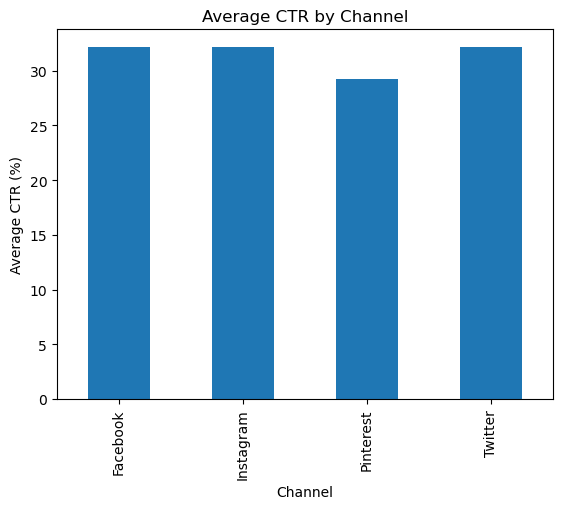

In [29]:
channel_ctr = df.groupby('Channel_Used')['CTR'].mean()
channel_ctr.plot(kind='bar')
plt.xlabel('Channel')
plt.ylabel('Average CTR (%)')
plt.title('Average CTR by Channel')
plt.show()

In [30]:
overall_pct = df['Channel_Used'].value_counts(normalize=True)
print(overall_pct)

Channel_Used
Facebook     0.250547
Instagram    0.250337
Pinterest    0.250273
Twitter      0.248843
Name: proportion, dtype: float64


In [31]:
low_ctr_pct = low_CTR['Channel_Used'].value_counts(normalize=True)
print(low_ctr_pct)

Channel_Used
Pinterest    0.380910
Facebook     0.215201
Instagram    0.203270
Twitter      0.200619
Name: proportion, dtype: float64


In [32]:
comparison = pd.concat([overall_pct, low_ctr_pct], axis=1)
comparison.columns = ['Overall_Share', 'LowCTR_Share']
comparison.head()

,Overall_Share,LowCTR_Share
Channel_Used,,
Facebook,0.250547,0.215201
Instagram,0.250337,0.203270
Pinterest,0.250273,0.380910
Twitter,0.248843,0.200619


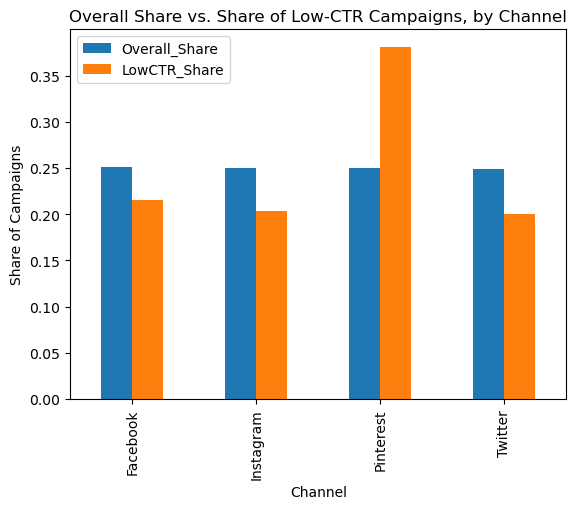

In [33]:
comparison.plot(kind='bar')
plt.xlabel('Channel')
plt.ylabel('Share of Campaigns')
plt.title('Overall Share vs. Share of Low-CTR Campaigns, by Channel')
plt.show()

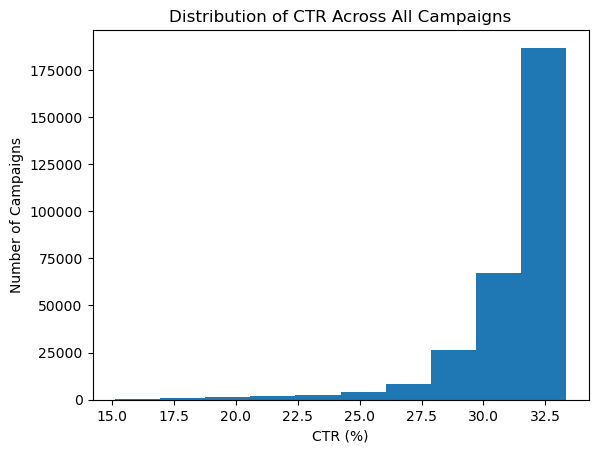

In [34]:
df['CTR'].plot(kind='hist')
plt.xlabel('CTR (%)')
plt.ylabel('Number of Campaigns')
plt.title('Distribution of CTR Across All Campaigns')
plt.show()